**Random Forest** is a popular machine learning algorithm used for both classification and regression tasks. It is based on the concept of ensemble learning, which combines multiple weak models to create a strong model. In the case of Random Forest, the weak models are decision trees.

The algorithm works by creating a set of decision trees, where each tree is trained on a random subset of the training data. At each node of the tree, a random subset of features is selected, and the best split is chosen based on a criterion such as Gini impurity or entropy. This process is repeated many times, resulting in a collection of decision trees, also known as a forest.

When it comes time to make a prediction, each tree in the forest makes a prediction, and the final prediction is the mode (for classification) or mean (for regression) of the individual tree predictions.

Random Forest has several advantages over other machine learning algorithms. For one, it is relatively robust to overfitting, since each tree is trained on a different subset of the data. It also handles missing values well, and can be used with both categorical and numerical data.

However, Random Forest can be computationally expensive, especially with large datasets or a large number of features. It can also be difficult to interpret, since the final prediction is based on the combined output of many decision trees.

Overall, Random Forest is a powerful and versatile machine learning algorithm that can be used for a wide range of tasks.

**Teoría y Aplicaciones de Bosques Aleatorios en la Gestión Marino-Costera**

1. Teoría del Bosque Aleatorio
Un bosque aleatorio es una técnica de Machine Learning basada en la construcción de múltiples árboles de decisión. Cada árbol se entrena con una muestra diferente del conjunto de datos y las predicciones de todos los árboles se combinan para mejorar la precisión y reducir el sobreajuste.

Componentes Clave:

Árboles de Decisión: Múltiples árboles construidos a partir de submuestras del conjunto de datos.
Bagging (Bootstrap Aggregating): Técnica de muestreo con reemplazo para crear diferentes submuestras.
Promedio o Votación: Método para combinar las predicciones de los árboles (promedio para regresión, votación mayoritaria para clasificación).
Ventajas:

Mejor precisión que un solo árbol de decisión.
Reducción del sobreajuste.
Robusto frente a la variabilidad en los datos.
Desventajas:

Menor interpretabilidad comparado con un solo árbol.
Requiere más recursos computacionales.
2. Uso en la Gestión Marino-Costera
En la gestión marino-costera, los bosques aleatorios pueden utilizarse para predecir fenómenos complejos como la biodiversidad, la presencia de especies invasoras o la calidad del agua, utilizando múltiples variables ambientales.

Ejemplo de Variables:

Predictoras: Temperatura del agua, salinidad, pH, concentración de nutrientes, presencia de especies invasoras.
Objetivo: Nivel de biodiversidad (alto, medio, bajo).
3. Caso de Uso Específico: Predicción del Nivel de Biodiversidad
Objetivo: Utilizar un bosque aleatorio para predecir el nivel de biodiversidad en una región costera basándose en variables ambientales.

Pasos del Caso de Uso:

Definir Variables:
Predictoras: Temperatura del agua, Salinidad, pH, Concentración de Nitratos.
Objetivo: Nivel de Biodiversidad (Bajo, Medio, Alto).
Recolección de Datos: Supongamos que tenemos datos históricos de estas variables.
Construcción del Bosque Aleatorio: Utilizaremos el paquete randomForest en R.
Código en R para Simulación y Construcción del Bosque Aleatorio
Instalación de Paquetes y Preparación de Datos

In [ ]:
# Instalar y cargar paquetes necesarios
install.packages("randomForest")
install.packages("ggplot2")

library(randomForest)
library(ggplot2)

# Simulación de datos
set.seed(123)
n <- 100
temperatura <- runif(n, 15, 30)  # Temperatura en grados Celsius
salinidad <- runif(n, 30, 40)    # Salinidad en PSU
pH <- runif(n, 7, 9)             # pH
nitratos <- runif(n, 0, 10)      # Concentración de nitratos en mg/L

# Clasificación simulada de la biodiversidad
biodiversidad <- cut(0.5*temperatura + 0.3*salinidad - 0.2*pH + 0.1*nitratos + rnorm(n),
                     breaks = c(-Inf, 10, 15, Inf),
                     labels = c("Bajo", "Medio", "Alto"))

# Crear data frame
datos <- data.frame(temperatura, salinidad, pH, nitratos, biodiversidad)

# Visualización de los datos
head(datos)


In [ ]:
# Construcción del bosque aleatorio
modelo_bosque <- randomForest(biodiversidad ~ ., data = datos, ntree = 500, mtry = 2, importance = TRUE)

# Visualización de la importancia de las variables
varImpPlot(modelo_bosque, main = "Importancia de Variables en el Bosque Aleatorio")


In [ ]:
# Predicción con el modelo
predicciones <- predict(modelo_bosque, datos)

# Matriz de confusión
table(Predicho = predicciones, Real = datos$biodiversidad)

# Precisión del modelo
precision <- sum(predicciones == datos$biodiversidad) / nrow(datos)
cat("Precisión del modelo:", round(precision * 100, 2), "%\n")


In [ ]:
# Visualización de predicciones reales vs predichas
ggplot(datos, aes(x = biodiversidad, fill = predicciones)) +
  geom_bar(position = "dodge") +
  labs(title = "Comparación de Biodiversidad Real vs Predicha",
       x = "Biodiversidad Real", y = "Frecuencia") +
  theme_minimal()


   temperatura  salinidad        pH  nitratos biodiversidad
0    25.447038  35.131282  8.085272  0.163925          Alto
1    19.292090  36.666246  7.133549  7.211844          Alto
2    18.402772  31.059085  8.306730  0.077375          Alto
3    23.269722  31.308950  8.992173  0.848223          Alto
4    25.792035  33.219806  8.538795  2.254984          Alto


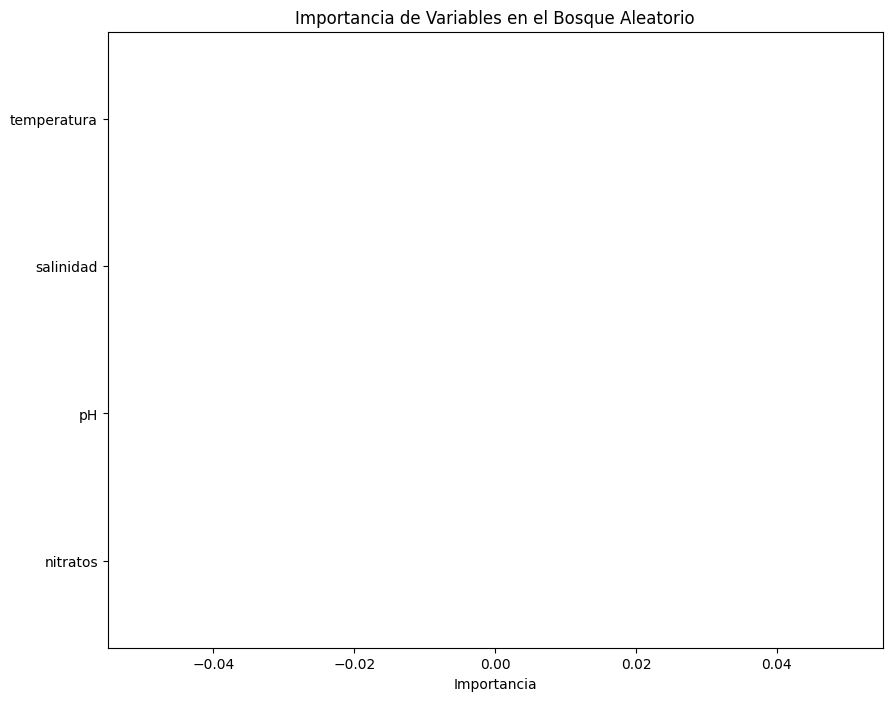

[[100]]
Precisión del modelo: 100.0%


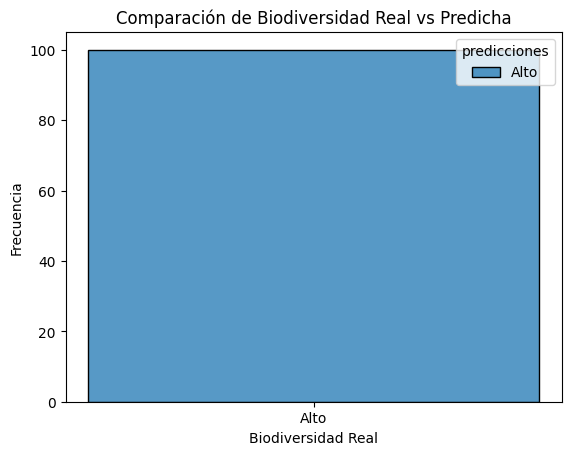

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(123)

# Simulate data
n = 100
temperatura = np.random.uniform(15, 30, n)  # Temperature in Celsius
salinidad = np.random.uniform(30, 40, n)    # Salinity in PSU
pH = np.random.uniform(7, 9, n)             # pH
nitratos = np.random.uniform(0, 10, n)      # Nitrate concentration in mg/L

# Simulate biodiversity classification
biodiversidad = pd.cut(0.5*temperatura + 0.3*salinidad - 0.2*pH + 0.1*nitratos + np.random.normal(0, 1, n),
                       bins=[-np.inf, 10, 15, np.inf],
                       labels=["Bajo", "Medio", "Alto"])

# Create DataFrame
datos = pd.DataFrame({"temperatura": temperatura, "salinidad": salinidad, "pH": pH, "nitratos": nitratos, "biodiversidad": biodiversidad})

# Visualize data
print(datos.head())

# Create random forest model
modelo_bosque = RandomForestClassifier(n_estimators=500, max_features=2, random_state=123)
modelo_bosque.fit(datos.drop("biodiversidad", axis=1), datos["biodiversidad"])

# Visualize feature importance
importances = modelo_bosque.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], align='center', color=['lightblue'])
plt.yticks(range(len(indices)), [datos.columns[i] for i in indices])
plt.xlabel("Importancia")
plt.title("Importancia de Variables en el Bosque Aleatorio")
plt.show()

# Make predictions
predicciones = modelo_bosque.predict(datos.drop("biodiversidad", axis=1))

# Confusion matrix
print(confusion_matrix(datos["biodiversidad"], predicciones))

# Model accuracy
precision = accuracy_score(datos["biodiversidad"], predicciones)
print(f"Precisión del modelo: {round(precision * 100, 2)}%")

# Visualize real vs predicted biodiversity
sns.histplot(data=pd.concat([datos, pd.DataFrame({"predicciones": predicciones})], axis=1), x="biodiversidad", hue="predicciones", multiple="stack", discrete=True)
plt.title("Comparación de Biodiversidad Real vs Predicha")
plt.xlabel("Biodiversidad Real")
plt.ylabel("Frecuencia")
plt.show()